#  **Requested vs Approved Quantity Analysis: Hyphothesis Testing**

The objective of this project is to determine:
* whether the quantities of malaria commodities requested by health facilities differ significantly from the quantities approved by the national Medical Store
* to identify whether these differences vary across product groups and facility types.

To achieve these objective the following steps will be conducted:
* Assumption Assessment: Determine whether the assumptions required for parametric statistical tests are satisfied
* Choice of the test: Decide on the test to conduct and provide the justification
* Global Hypothesis Testing: Determine whether approved quantities differ significantly from requested quantities across all products and facilities type
* Stratified Hypothesis Testing: Assess whether allocation behavior differs across operational contexts: Products and facilities type
* Interpretation: Translate statistical findings into operational conclusions.


## Loading the dataset and import packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm

In [65]:
df_pairedqty_allproducts=pd.read_csv('../data/dataset_pairedqty_allproduct.csv')

### Explore the dataset with all products

In [3]:
#View a sample of data
df_pairedqty_allproducts.head()

,product_primary_name,processing_periods_name,facility_type_name,quantity_requested,quantity_approved,pack_size,dispensing_unit,allocation_gap
0,PYRA-COMP,2025-05-01,HEALTH CENTER,NaN,0.0,1,TABLET,0.0
1,ACT-GC,2025-05-01,HEALTH CENTER,NaN,620.0,30,BLISTER,620.0
2,ACT-AD,2024-02-01,HEALTH CENTER,NaN,13.0,30,BLISTER,13.0
3,ART-SUP,2024-08-01,HEALTH CENTER,NaN,0.0,2,CAPSULE,0.0
4,RDT,2024-02-01,HEALTH CENTER,NaN,319.0,25,PIECE,319.0


In [4]:
#Summary of the dataset
df_pairedqty_allproducts.describe()

,quantity_requested,quantity_approved,pack_size,allocation_gap
count,2420.000000,8763.000000,8763.000000,8763.000000
mean,745.470661,832.614401,180.924227,626.744380
std,487.625668,2075.873748,362.624183,2081.540296
min,17.000000,0.000000,1.000000,-2628.000000
25%,391.000000,1.000000,5.000000,0.000000
50%,639.000000,42.000000,30.000000,9.000000
75%,1004.250000,597.000000,30.000000,426.000000
max,2950.000000,52652.000000,1000.000000,49702.000000


### Explore the dataset with ACT products group only

In [5]:
#View a sample of data
df_pairedqty_actgroup.head()

,product_primary_name,processing_periods_name,facility_type_name,quantity_requested,quantity_approved,pack_size,dispensing_unit,allocation_gap
0,ACT-GC,2025-05-01,HEALTH CENTER,NaN,620.0,30,BLISTER,620.0
1,ACT-AD,2024-02-01,HEALTH CENTER,NaN,13.0,30,BLISTER,13.0
2,ACT-SC,2024-05-01,HEALTH CENTER,NaN,2.0,30,BLISTER,2.0
3,ACT-INF,2025-11-01,HEALTH CENTER,NaN,12.0,30,BLISTER,12.0
4,ACT-INF,2024-08-01,HEALTH CENTER,NaN,499.0,30,BLISTER,499.0


In [6]:
#Summary of the dataset
df_pairedqty_actgroup.describe()

,quantity_requested,quantity_approved,pack_size,allocation_gap
count,800.000000,2945.000000,2945.0,2945.000000
mean,754.711250,862.718506,30.0,657.703565
std,488.245986,2031.672909,0.0,2034.054157
min,25.000000,0.000000,30.0,-2622.000000
25%,393.250000,1.000000,30.0,0.000000
50%,650.500000,54.000000,30.0,11.000000
75%,1008.250000,702.000000,30.0,482.000000
max,2630.000000,20596.000000,30.0,20596.000000


## Assumption Assessment

### Assumption 1: Independence between Observations

Before concluding that the independence assumption is satisfied, verify that your dataset contains no duplicate ordering events. 
However our case is clear and straightforward

The **independence assumption** is satisfied for the purpose of a paired hypothesis test since:
* each row corresponds to one facility, one product and one ordering period
* each ordering event is recorded only once
* the ordering decision for one facility does not directly determine the ordering decision of another facility within the same period

### Assumption 2: Independence of Observations

At this step, we are going to check the normality of the allocation gap variable. 

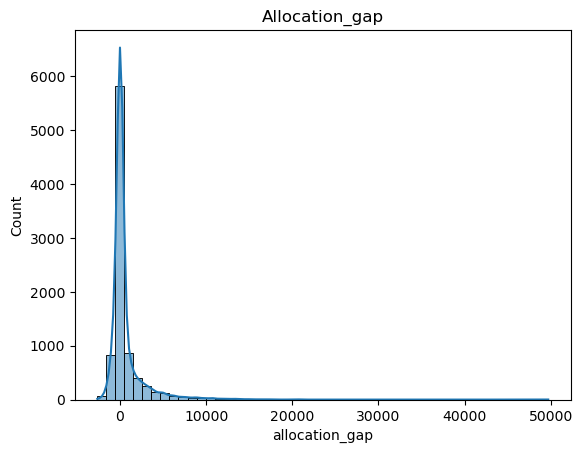

In [7]:
sns.histplot(df_pairedqty_allproducts["allocation_gap"], bins=50, kde=True)
plt.title('Allocation_gap');
plt.show()

The histogram of the allocation_gap shows a strongly right-skewed distribution, with most observations concentrated around zero and a long positive tail extending to approximately 50,000 units. The pronounced asymmetry and heavy right tail indicate that the distribution  does not follow the normal distribution

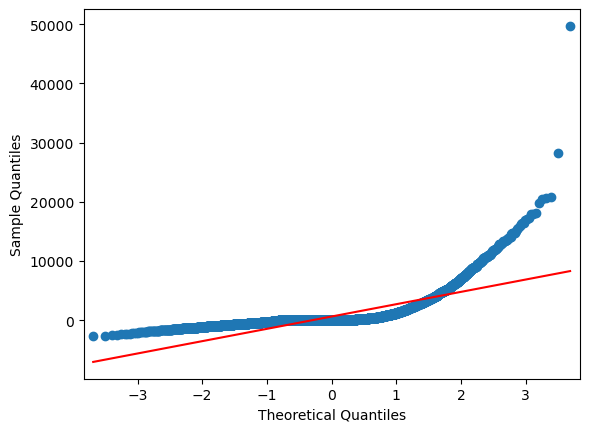

In [8]:
fig=sm.qqplot(df_pairedqty_allproducts['allocation_gap'],line='s')
plt.show()

The Q-Q plot further confirms the lack of normality. If the allocation gap followed a normal distribution, the sample quantiles would closely follow the reference diagonal line. Instead, the observations deviate markedly from the line, particularly in the upper quantiles where the points rise sharply above the reference line.

## Choice of the test

Even if the standard paired **t-test** can often tolerate moderate departures from normality when the sample size is large (2,420 observations), the data exhibit more than moderate departures: pronounced right skewness, heavy tails, numerous operational outliers.
So we need a test that:
* is appropriate for your paired design (requested vs. approved quantities)
* does not assume normality of the paired differences
* is robust to skewed distributions
* is less influenced by the extreme positive allocation gaps identified during the EDA

Given these characteristics, the **Wilcoxon Signed-Rank Test** is likely to provide a more robust primary analysis. For completeness, I may also perform the paired t-test as a sensitivity analysis. If both tests lead to the same conclusion, it will strengthen the credibility of your findings

## Hypothesis Testing: Global profile

Because your assumption checking indicates that I will  use the Wilcoxon Signed-Rank Test, the hypotheses should be stated in terms of the median difference. The difference is the paired difference between the quantity requested and the quantity approved = allocation_gap.

To determine whether approved quantities differ significantly from requested quantities across all products and facilities type.
The formulation of hypothesis is:

**H₀ (Null Hypothesis)**  
Across all products and facility types, there is **no significant difference** between quantities requested by facilities and quantities approved at the national level.
* H0: Median(allocation_gap) = 0

**H₁ (Alternative Hypothesis)**  
Across all products and facility types, the quantities approved at the national level **differ significantly** from the quantities requested by facilities.
* H1: Median(allocation_gap) <> 0



Rejecting the null hypothesis would indicate that the quantities approved by the Medical Store differ systematically from those requested by health facilities.

In [9]:
significance_level = 0.05

In [10]:
from scipy.stats import wilcoxon
# Removing zero difference (allocation_gap) is common for a clean signed-rank test
df_test = df_pairedqty_allproducts[df_pairedqty_allproducts["allocation_gap"] != 0].copy()
#Run Wilcoxon Signed-Rank Test
stat, pvalue = wilcoxon(
    df_test["allocation_gap"]
)
print("Wilcoxon statistic:", stat)
print("p-value:", pvalue)

Wilcoxon statistic: 7759824.0
p-value: 7.578481842392077e-195


* With a p-value of 7.58 × 10e-195 which is smaller than 0.05, the **null hypothesis is rejected in favor of the alternative hypothesis**. 

* Therefore, we can conclude at the 5% significance level that the median allocation gap differs significantly from zero. In other words, the quantities of malaria commodities approved by the central level differ systematically from the quantities requested by health facilities.

* This finding confirms that the observed differences are highly unlikely to have occurred by random variation alone.

## Construct the confidence interval

The hypothesis testing shows that the quantities of malaria commodities approved by the central level differ systematically from the quantities requested by health facilitie. However, statistical significance does not necessarily imply operational significance. The magnitude and practical importance of this difference should therefore be assessed using complementary measures such as confifence intervals.

Median allocation gap = 9 units, this value is only an estimate of the true median allocation gap for the entire population of health facilities and products.
If we had collected data from a different sample of facilities or during a different period, the median would probably not be exactly 9.

The Confidence intervals give data professionals a way to answer the question **"How uncertain is the Median(allocation_gap) ?"** by providing a plausible range for the population parameter.

The construct the confidence intervals, we will use the following framework:
* 1. Identify the sample statistic
  2. choose a confidence level
  3. Find the margin of error
  4. construct a confidence interval

 **1.Identify the sample statistic**

In this study, the key statistic is the median allocation gap:

In [44]:
sample_statistic = df_pairedqty_allproducts["allocation_gap"].median()

In [45]:
print('sample_statistic: ',sample_statistic)

sample_statistic:  9.0


**2.Choose the confidence level**

In [46]:
#Use a 95% confidence level.
confidence_level = 0.95

This means that, if we repeated the sampling process many times, about 95% of the constructed intervals would contain the true median allocation gap.

**3.Estimate the margin of error**

Because the allocation gap is non-normal `(z-score × standard error)`, we use bootstrap resampling to estimate uncertainty around the median. 

In [ ]:
gap = df_pairedqty_allproducts["allocation_gap"].dropna().values
n_bootstrap = 10000
bootstrap_medians = []
np.random.seed(42)
for i in range(n_bootstrap):
    sample = np.random.choice(gap, size=len(gap), replace=True)
    bootstrap_medians.append(np.median(sample))


**4.Construct the confidence interval**

In [16]:
#Then calculate the 95% confidence limits. It leaves from 2.5 lower tail and 2.5 upper tail (100-2.5)=97.5
lower_limit = np.percentile(bootstrap_medians, 2.5)
upper_limit = np.percentile(bootstrap_medians, 97.5)
print("95% confidence interval:", lower_limit, "to", upper_limit)

95% confidence interval: 7.0 to 12.0


* From the statistic perspective, 95% confidence interval [7 : 12]  means that if the same sampling were repeated many times, approximately 95% of the resulting confidence intervals would contain the true population median allocation gap. **(Misinterpretation)** It does not mean that there is a 95% probability that the true median lies between 7 and 12 units; rather, it reflects the long-run performance of the estimation method.
* From the supply chain perspective, the confidence interval provides important information about the typical allocation behavior of the central level (program). Because both the lower limit (7 units) and the upper limit (12 units) are positive and the interval does not include zero, the analysis indicates that the typical approved quantity is consistently higher than the quantity requested by health facilities and products. This indicates that facilities receive a median of at least 7 additional units beyond their requested quantities.
* This finding strengthens the conclusion of the Wilcoxon Signed-Rank Test by showing that the observed positive allocation gap is not only statistically significant but also consistently positive across the population.

## Stratified Hypothesis Testing

The stratified analysis should answer two related but distinct questions:

* Within each subgroup: Are approved quantities significantly different from requested quantities?
* Between subgroups: Is the allocation gap significantly different across product groups or facility types?

Although one-way and two-way ANOVA are commonly used to compare mean differences across groups, they were not selected for this study because the exploratory data analysis demonstrated that the assumptions **(Normality of variable, homogeinity of variance, independance)** underlying ANOVA were not satisfied.

The exploratory data analysis showed that quantity requested, quantity approved, and the resulting allocation gap were all highly non-normally distributed, exhibiting strong positive skewness, heavy-tailed distributions, and numerous operational outliers. Given these characteristics, the assumptions required for parametric ANOVA were not met.

Therefore, the stratified analyses employed non-parametric methods that do not require normality, namely the Wilcoxon Signed-Rank Test for paired comparisons and the Kruskal–Wallis test for comparisons across independent product groups and facility types. This approach ensures that the statistical inferences remain consistent with the observed properties of the data.

### 1.Analysis by Product Group

**1.Prepare the stratified paired dataset by  Identifying each product_group:**
*  Group ACT: ACT-INF,ACT-SC,ACT-GC,ACT-AD
*  Group PYRA: PYRA-COMP,PYRA-SAC
*  Group ART: ART-INJ,ART-SUP
*  Group SP: QUIN,SP
*  Group PREV: ITN,RDT

In [17]:
product_group_mapping = {
    'ACT-INF': 'ACT',
    'ACT-SC': 'ACT',
    'ACT-GC': 'ACT',
    'ACT-AD': 'ACT',
    'PYRA-COMP': 'PYRA',
    'PYRA-SAC': 'PYRA',
    'ART-INJ': 'ART',
    'ART-SUP': 'ART',
    'QUIN': 'SP',
    'SP': 'SP',
    'ITN': 'PREV',
    'RDT': 'PREV'
}

df_pairedqty_allproducts['product_group'] = (
    df_pairedqty_allproducts['product_primary_name']
    .map(product_group_mapping)
    .fillna('Other')
)
df_pairedqty_allproducts.head()

,product_primary_name,processing_periods_name,facility_type_name,quantity_requested,quantity_approved,pack_size,dispensing_unit,allocation_gap,product_group
0,PYRA-COMP,2025-05-01,HEALTH CENTER,NaN,0.0,1,TABLET,0.0,PYRA
1,ACT-GC,2025-05-01,HEALTH CENTER,NaN,620.0,30,BLISTER,620.0,ACT
2,ACT-AD,2024-02-01,HEALTH CENTER,NaN,13.0,30,BLISTER,13.0,ACT
3,ART-SUP,2024-08-01,HEALTH CENTER,NaN,0.0,2,CAPSULE,0.0,ART
4,RDT,2024-02-01,HEALTH CENTER,NaN,319.0,25,PIECE,319.0,PREV


In [18]:
# Confirm the available categories and sample sizes
print(df_pairedqty_allproducts["product_group"].value_counts())
print(df_pairedqty_allproducts["facility_type_name"].value_counts())

print(
    df_pairedqty_allproducts.groupby(
        ["product_group", "facility_type_name"]
    ).size()
)

product_group
ACT     2945
ART     1528
PREV    1514
SP      1434
PYRA    1342
Name: count, dtype: int64
facility_type_name
HEALTH CENTER        8091
DISTRICT HOSPITAL     512
REGIONAL HOSPITAL     114
NATIONAL HOSPITAL      46
Name: count, dtype: int64
product_group  facility_type_name
ACT            DISTRICT HOSPITAL      166
               HEALTH CENTER         2726
               NATIONAL HOSPITAL       16
               REGIONAL HOSPITAL       37
ART            DISTRICT HOSPITAL       92
               HEALTH CENTER         1412
               NATIONAL HOSPITAL        8
               REGIONAL HOSPITAL       16
PREV           DISTRICT HOSPITAL       84
               HEALTH CENTER         1402
               NATIONAL HOSPITAL        6
               REGIONAL HOSPITAL       22
PYRA           DISTRICT HOSPITAL       91
               HEALTH CENTER         1229
               NATIONAL HOSPITAL        8
               REGIONAL HOSPITAL       14
SP             DISTRICT HOSPITAL       7

In [19]:
df_pairedqty_allproducts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_primary_name     8763 non-null   object 
 1   processing_periods_name  8763 non-null   object 
 2   facility_type_name       8763 non-null   object 
 3   quantity_requested       2420 non-null   float64
 4   quantity_approved        8763 non-null   float64
 5   pack_size                8763 non-null   int64  
 6   dispensing_unit          8763 non-null   object 
 7   allocation_gap           8763 non-null   float64
 8   product_group            8763 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 616.3+ KB


**2.Describe allocation gaps within each product group**

For each product group, calculate:
* number of paired observations;
* median requested quantity;
* median approved quantity;
* median allocation gap;
* interquartile range;


In [20]:
# Named Aggregation formula
product_summary = (
    df_pairedqty_allproducts.groupby("product_group")
    .agg(
        n=("allocation_gap", "size"),
        median_requested=("quantity_requested", "median"),
        median_approved=("quantity_approved", "median"),
        median_gap=("allocation_gap", "median"),
        q1_gap=("allocation_gap", lambda x: x.quantile(0.25)),
        q3_gap=("allocation_gap", lambda x: x.quantile(0.75)),
    )
)

product_summary["iqr_gap"] = (
    product_summary["q3_gap"] - product_summary["q1_gap"]
)

product_summary

,n,median_requested,median_approved,median_gap,q1_gap,q3_gap,iqr_gap
product_group,,,,,,,
ACT,2945,650.5,54.0,11.0,0.0,482.00,482.00
ART,1528,654.0,33.5,7.0,0.0,341.00,341.00
PREV,1514,641.0,43.0,7.0,0.0,475.75,475.75
PYRA,1342,643.0,45.0,14.0,0.0,499.00,499.00
SP,1434,594.0,32.0,6.0,0.0,326.50,326.50


* The descriptive statistics reveal moderate differences in demand and allocation across malaria product groups. Median requested quantities range from 594 units for SP to 654 units for ART, indicating relatively comparable ordering volumes among product groups. Same for the median approved quantities
* The median allocation gap is positive for all product groups, varying between 6 units (SP) and 14 units (PYRA), indicating that the typical allocation event results in slightly higher approved quantities than requested quantities.
*  The first quartile of the allocation gap is zero for all groups, meaning that at least 25% of allocation events had no difference between approved and requested quantities.
* The interquartile range variation also suggests that the variability of allocation decisions differs across product groups, with PYRA and ACT exhibiting the greatest dispersion.


**3. Conduct a Wilcoxon test within each product group**

Assess whether allocation behavior differs across Products group. The formulation of hypothesis is:

**H₀ (Null Hypothesis)**  
Within the product group, there is no significant difference between the quantities requested by health facilities and the quantities approved at the national level.
* H₀g: Median(Allocation Gap)=0

**H₁ (Alternative Hypothesis)**   
Within the product group, the quantities approved at the national level differ significantly from the quantities requested by health facilities.
* H₁g: Median(Allocation Gap)<>0


In [26]:
from scipy.stats import wilcoxon
product_results = []
df_test = None
for group, subset in df_pairedqty_allproducts.groupby("product_group"):
    gaps = subset["allocation_gap"].dropna()
    df_test = gaps[gaps != 0]
    if len(df_test) == 0:
        continue
    statistic, p_value = wilcoxon(
        df_test,
        alternative="two-sided"
    )
    product_results.append({
        "product_group": group,
        "n_total": len(gaps),
        "n_nonzero": len(df_test),
        "median_gap": gaps.median(),
        "wilcoxon_statistic": statistic,
        "p_value_raw": p_value
    })
product_results = pd.DataFrame(product_results)

In [23]:
product_results

,product_group,n_total,n_nonzero,median_gap,wilcoxon_statistic,p_value_raw
0,ACT,2945,2416,11.0,822734.0,4.667220e-77
1,ART,1528,1266,7.0,266412.0,4.428315e-25
2,PREV,1514,1249,7.0,233717.0,1.129854e-34
3,PYRA,1342,1113,14.0,175841.0,7.005633e-36
4,SP,1434,1176,6.0,211832.5,1.036127e-30


* With all p-values smaller than 0.05, the **null hypothesis is rejected in favor of the alternative hypothesis** within each products groups. 

* Therefore, we can conclude at the 5% significance level that the median allocation gap differs significantly from zero within each group. In other words, all malaria product groups exhibit statistically significant differences between the quantities requested by health facilities and the quantities approved at the national level.

* These findings suggest that the systematic difference observed in the global analysis is not driven by a single product category but is consistent across all malaria product groups, with only minor variations in the magnitude of the allocation gap

* the consistently positive median gaps indicate that the typical approved quantity exceeds the requested quantity for all malaria commodity groups.


### Construct the confidence interval by product group

The stratified Wilcoxon Signed-Rank Tests showed that, for all product groups, the quantities of malaria commodities approved at the national level differ significantly from the quantities requested by health facilities.

However, as with the global analysis, statistical significance alone does not indicate the magnitude or operational importance of these differences.
For each product group, the observed median allocation gap is only an estimate of the true population median for that specific subgroup. If a different sample of facilities, products, or ordering periods had been observed, the estimated median allocation gap would likely vary. 

Consequently, it is important to assess the uncertainty associated with each subgroup estimate. 
Confidence intervals provide a practical way to answer the question:
**How uncertain is the estimated median allocation gap within each product group ?**

By estimating a plausible range for the true population median allocation gap, confidence intervals complement the hypothesis tests by providing information on the precision and practical significance of the observed allocation differences within each group of products.

To construct the confidence intervals for each subgroup, the same bootstrap approach used in the global analysis was applied according to the following framework:

1. Identify the sample statistic
2. Choose a confidence level (95% confidence level).
3. Estimate the margin of error using bootstrap resampling.
4. Construct the confidence interval by estimating the lower and upper confidence limits from the bootstrap distribution.

 **1.Identify the sample statistic**

In this study, the key statistic is the median allocation gap for each product group:

In [35]:
sample_statistic = df_pairedqty_allproducts.groupby('product_group')['allocation_gap'].median()

In [36]:
sample_statistic

product_group
ACT     11.0
ART      7.0
PREV     7.0
PYRA    14.0
SP       6.0
Name: allocation_gap, dtype: float64

**2.Choose the confidence level**

In [37]:
#Use a 95% confidence level.
confidence_level = 0.95

**3.Estimate the margin of error and a 95% confidence interval**

In [39]:
def bootstrap_median_ci(series, n_bootstrap=10000, confidence=0.95, seed=42):
    values = series.dropna().values
    bootstrap_medians = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        sample = np.random.choice(values, size=len(values), replace=True)
        bootstrap_medians[i] = np.median(sample)
    alpha = 1 - confidence

    lower = np.percentile(
        bootstrap_medians,
        100 * alpha / 2
    )
    upper = np.percentile(
        bootstrap_medians,
        100 * (1 - alpha / 2)
    )

    return pd.Series({
        "median_gap": np.median(values),
        "ci_lower": lower,
        "ci_upper": upper
    })


In [58]:
product_ci = (
    df_pairedqty_allproducts.groupby("product_group")["allocation_gap"]
    .apply(bootstrap_median_ci)
    .unstack()
)
product_ci = product_ci.reset_index()
product_ci

,product_group,median_gap,ci_lower,ci_upper
0,ACT,11.0,7.0,16.0000
1,ART,7.0,4.0,11.5000
2,PREV,7.0,5.0,15.0000
3,PYRA,14.0,7.5,22.0125
4,SP,6.0,4.0,11.0000


* From a statistical perspective, the 95% bootstrap confidence intervals estimate the range within which the true population median allocation gap is expected to lie for each malaria product group. For example, the ACT group has a 95% confidence interval of [8 : 16], meaning that if the same sampling procedure were repeated many times, approximately 95% of the resulting confidence intervals would contain the true median allocation gap for ACT products. This interpretation applies similarly to the ART [4 : 12], PREV [5 : 15], PYRA [7.5 : 23], and SP [3.5 : 11] groups.
* From a supply chain perspective, all confidence intervals are entirely positive and do not include zero, indicating that the typical approved quantity is consistently higher than the requested quantity across all malaria product groups. Facilities receive additional quantities beyond those requested, ranging from approximately 3.5 units for SP, 8 units for ACT, 7.5 units for PYRA. Among the five groups, PYRA exhibits the widest confidence interval, suggesting greater uncertainty and variability in the typical allocation gap, whereas SP and ART have narrower intervals, indicating more precise estimates.
* These confidence intervals reinforce the Wilcoxon Signed-Rank Test results, confirming that the positive allocation gaps observed for each product group are not only statistically significant but also consistently positive across the corresponding populations. The overlap between several confidence intervals further suggests that, although the magnitude of the allocation gap varies slightly among product groups, the overall allocation pattern appears broadly similar.


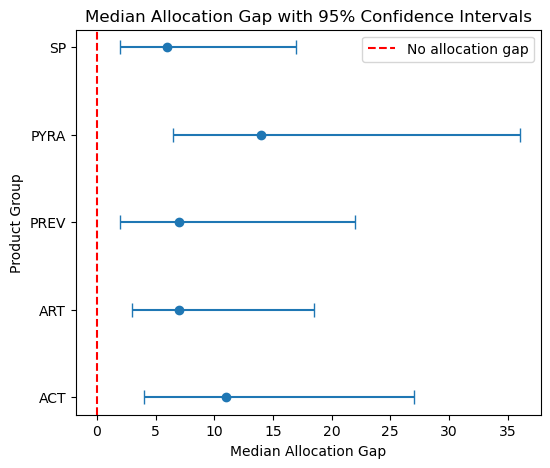

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(6,5))

plt.errorbar(
    product_ci["median_gap"],
    product_ci["product_group"],
    xerr=[product_ci["ci_lower"], product_ci["ci_upper"]],
    fmt='o',
    capsize=5
)

plt.axvline(0,
            color='red',
            linestyle='--',
            label='No allocation gap')

plt.xlabel("Median Allocation Gap")
plt.ylabel("Product Group")
plt.title("Median Allocation Gap with 95% Confidence Intervals")
plt.legend()

As all median allocation gaps are positive and the confidence intervals overlap considerably, the graphical evidence suggests that allocation behavior is broadly similar across the five malaria product groups. Consequently, the stratified Wilcoxon Signed-Rank Tests were considered sufficient to demonstrate that the positive allocation pattern is consistently observed across product groups, and no additional between-group comparison was pursued.

### 1.Analysis by Facility Type

**1.Describe allocation gaps within each facilities type**

For each facilities typpe, calculate:
* number of paired observations;
* median requested quantity;
* median approved quantity;
* median allocation gap;
* interquartile range;

In [25]:
facility_summary = (
    df_pairedqty_allproducts.groupby("facility_type_name")
    .agg(
        n=("allocation_gap", "size"),
        median_requested=("quantity_requested", "median"),
        median_approved=("quantity_approved", "median"),
        median_gap=("allocation_gap", "median"),
        q1_gap=("allocation_gap", lambda x: x.quantile(0.25)),
        q3_gap=("allocation_gap", lambda x: x.quantile(0.75)),
    )
)
facility_summary["iqr_gap"] = (
    facility_summary["q3_gap"] - facility_summary["q1_gap"]
)
facility_summary

,n,median_requested,median_approved,median_gap,q1_gap,q3_gap,iqr_gap
facility_type_name,,,,,,,
DISTRICT HOSPITAL,512,622.0,28.0,5.0,0.0,344.50,344.50
HEALTH CENTER,8091,640.0,43.0,10.0,0.0,429.00,429.00
NATIONAL HOSPITAL,46,757.0,5.0,0.0,0.0,305.75,305.75
REGIONAL HOSPITAL,114,546.5,24.0,11.0,0.0,577.00,577.00


* The descriptive statistics reveal differences in both demand and allocation across facility types. Median requested quantities range from 546.5 units for Regional Hospitals to 757 units for National Hospitals, indicating that ordering volumes vary by facility level.
* Median approved quantities also differ substantially, ranging from 5 units for National Hospitals to 43 units for Health Centers. Despite these differences in demand and approval levels, the median allocation gap remains small, varying between 0 and 11 units across facility types.
* Health Centers and Regional Hospitals exhibit the largest median allocation gaps (10 and 11 units, respectively), whereas National Hospitals have a median allocation gap of 0 units, suggesting that the typical approved quantity equals the requested quantity for this subgroup. However, the National Hospital subgroup contains only 46 paired observations, and these results should therefore be interpreted with caution.
* The interquartile range variation also suggests that the variability of allocation decisions differs across facility_type, with Regional Hospitals exhibiting the greatest dispersion.


**2. Conduct a Wilcoxon test within each facility type**

Assess whether allocation behavior differs across facility types. The formulation of hypothesis is:

**H₀ (Null Hypothesis)**  
Within the facilities type, there is no significant difference between the quantities requested by health facilities and the quantities approved at the national level.
* H₀f: Median(Allocation Gap)=0

**H₁ (Alternative Hypothesis)**   
Within the facilities type, the quantities approved at the national level differ significantly from the quantities requested by health facilities.
* H₁f: Median(Allocation Gap)<>0

In [27]:
from scipy.stats import wilcoxon
product_results = []
df_test = None
for group, subset in df_pairedqty_allproducts.groupby("facility_type_name"):
    gaps = subset["allocation_gap"].dropna()
    df_test = gaps[gaps != 0]
    if len(df_test) == 0:
        continue
    statistic, p_value = wilcoxon(
        df_test,
        alternative="two-sided"
    )
    product_results.append({
        "facility_type": group,
        "n_total": len(gaps),
        "n_nonzero": len(df_test),
        "median_gap": gaps.median(),
        "wilcoxon_statistic": statistic,
        "p_value_raw": p_value
    })
product_results = pd.DataFrame(product_results)
product_results

,facility_type,n_total,n_nonzero,median_gap,wilcoxon_statistic,p_value_raw
0,DISTRICT HOSPITAL,512,414,5.0,26545.5,1.638671e-11
1,HEALTH CENTER,8091,6683,10.0,6643567.0,6.679859e-181
2,NATIONAL HOSPITAL,46,32,0.0,215.0,3.595158e-01
3,REGIONAL HOSPITAL,114,91,11.0,967.5,8.401337e-06


* The p-values of District Hospital, Health centers and Regional Hospital are smaller than 0.05, the **null hypothesis is rejected in favor of the alternative hypothesis** within these facilty type. 

* Therefore, we can conclude at the 5% significance level that the median allocation gap differs significantly from zero within District Hospital, Health centers and Regional Hospital. In other words, these facilities type exhibit statistically significant differences between the quantities requested by health facilities and the quantities approved at the national level.

* In contrast, National Hospitals show **no statistically significant difference** between requested and approved quantities (p = 0.360), and the median allocation gap is 0 units. However, this subgroup contains a very small size, which provides limited statistical power. Consequently, the absence of a significant difference for National Hospitals should be interpreted with caution.

* Overall, these findings indicate that the systematic allocation differences observed in the global analysis are present across most facility types, with the exception of National Hospitals, where the small sample size limits definitive conclusions.

### Construct the confidence interval by facility type

The stratified Wilcoxon Signed-Rank Tests showed that, for all facility type, the quantities of malaria commodities approved at the national level differ significantly from the quantities requested by health facilities.

Consequently, it is important to assess the uncertainty associated with each subgroup estimate. 
Confidence intervals provide a practical way to answer the question:
**How uncertain is the estimated median allocation gap within each facility type ?**

the similar process to construct the confidence intervals for each subgroup, will be applied.

**1.Identify the sample statistic**

In this study, the key statistic is the median allocation gap for each facility type:


In [48]:
sample_statistic = df_pairedqty_allproducts.groupby('facility_type_name')['allocation_gap'].median()
sample_statistic

facility_type_name
DISTRICT HOSPITAL     5.0
HEALTH CENTER        10.0
NATIONAL HOSPITAL     0.0
REGIONAL HOSPITAL    11.0
Name: allocation_gap, dtype: float64

**2.Choose the confidence level**

In [49]:
#Use a 95% confidence level.
confidence_level = 0.95

**3.Estimate the margin of error and a 95% confidence interval**

In [50]:
def bootstrap_median_ci(series, n_bootstrap=10000, confidence=0.95, seed=42):
    values = series.dropna().values
    bootstrap_medians = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        sample = np.random.choice(values, size=len(values), replace=True)
        bootstrap_medians[i] = np.median(sample)
    alpha = 1 - confidence

    lower = np.percentile(
        bootstrap_medians,
        100 * alpha / 2
    )
    upper = np.percentile(
        bootstrap_medians,
        100 * (1 - alpha / 2)
    )

    return pd.Series({
        "median_gap": np.median(values),
        "ci_lower": lower,
        "ci_upper": upper
    })


In [56]:
facility_ci = (
    df_pairedqty_allproducts.groupby("facility_type_name")["allocation_gap"]
    .apply(bootstrap_median_ci)
    .unstack()
)
facility_ci= facility_ci.reset_index()
facility_ci

,facility_type_name,median_gap,ci_lower,ci_upper
0,DISTRICT HOSPITAL,5.0,2.0,14.0000
1,HEALTH CENTER,10.0,7.0,12.0000
2,NATIONAL HOSPITAL,0.0,0.0,11.0000
3,REGIONAL HOSPITAL,11.0,3.0,89.0125


* From a statistical perspective, the 95% bootstrap confidence intervals estimate the range within which the true population median allocation gap is expected to lie for each facility type. For example, Health Centers have a 95% confidence interval of [7 : 12], indicating that if the same sampling procedure were repeated many times, approximately 95% of the resulting confidence intervals would contain the true median allocation gap for Health Centers. The same interpretation applies to District Hospitals [2 : 14], Regional Hospitals [3 : 76], and National Hospitals [0 : 11].
* From a supply chain perspective, the confidence intervals for Health Centers, District Hospitals, and Regional Hospitals are entirely positive, indicating that the typical approved quantity is consistently higher than the quantity requested within these facility types.
* In contrast, the confidence interval for National Hospitals begins at 0, suggesting that the typical allocation gap may be zero, which is consistent with the non-significant Wilcoxon Signed-Rank Test result for this subgroup. However, this finding should be interpreted cautiously because the National Hospital subgroup contains only 46 paired observations.
* Furthermore, Regional Hospitals exhibit the widest confidence interval ([3 : 76]), indicating greater uncertainty and variability in the estimated median allocation gap, whereas Health Centers have the narrowest interval ([7 : 12]), reflecting a more precise estimate due to the substantially larger sample size.
* These confidence intervals support the Wilcoxon Signed-Rank Test results, confirming that the positive allocation gaps observed for Health Centers, District Hospitals, and Regional Hospitals are not only statistically significant but also consistently positive within their respective populations.

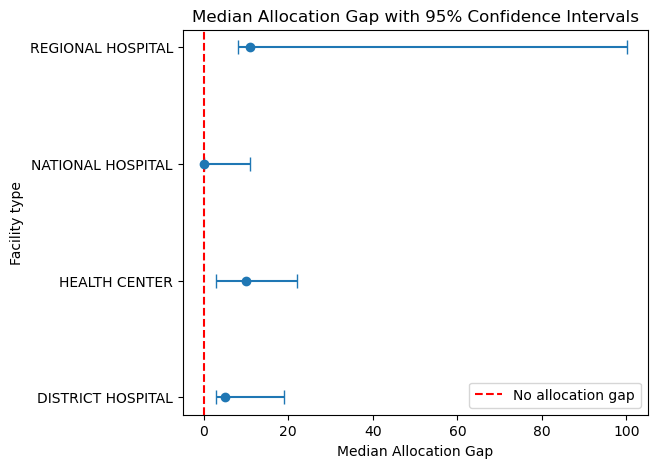

In [62]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(6,5))

plt.errorbar(
    facility_ci["median_gap"],
    facility_ci["facility_type_name"],
    xerr=[facility_ci["ci_lower"], facility_ci["ci_upper"]],
    fmt='o',
    capsize=5
)

plt.axvline(0,
            color='red',
            linestyle='--',
            label='No allocation gap')

plt.xlabel("Median Allocation Gap")
plt.ylabel("Facility type")
plt.title("Median Allocation Gap with 95% Confidence Intervals")
plt.legend()

Overall, the confidence intervals overlap substantially across facility types, suggesting that the magnitude of the median allocation gap is broadly similar. The wider confidence interval observed for Regional Hospitals reflects greater uncertainty in the estimated median allocation gap, whereas the narrower interval for Health Centers indicates a more precise estimate due to the much larger sample size. Overall, **the confidence intervals provide no strong descriptive indication of marked differences in allocation behavior across facility types**.

## General Conclusion
The global analysis demonstrated a statistically significant difference between requested and approved quantities. Stratified analyses showed that this finding was consistent across all malaria product groups and across facility type. The confidence intervals further confirmed that the typical allocation gap remained positive within these operational contexts. Together, these results indicate that the observed allocation pattern is not confined to a specific product group or facility type but is broadly observed throughout the health supply chain.